# Undirected

In [30]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from utils.plotting import plot_graph_with_omitted
import utils.link_prediction as lp
from tests.tests import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:


data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()

data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


IndexError: tuple index out of range

# Directed

## Imports

In [4]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils as upyg
from utils import utils
from tests import *
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from datasets.import_dataset import import_dataset
from trainer_directed import Trainer
import clamiter_directed as ci
from utils.plotting import *
import utils.link_prediction as lp
from tests.tests import *

import networkx as nx
import matplotlib.pyplot as plt


def plot_directed_graph(data):
    """
    Plot a directed graph from a PyG Data object.
    
    Args:
        data: PyG Data object containing edge_index
    """
    # Create directed graph
    G = nx.DiGraph()

    # Add nodes
    nodes = torch.unique(data.edge_index).tolist()
    G.add_nodes_from(nodes)

    # Add edges and track edge colors
    edges = list(zip(data.edge_index[0].tolist(), data.edge_index[1].tolist()))
    edge_colors = ['red' if attr else 'black' for attr in data.edge_attr.tolist()]
    G.add_edges_from(edges)

    # Draw graph
    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=500, arrowsize=20, width=2,
            arrows=True, edge_color=edge_colors)
    plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Omittion Functionality

omitted edges (B) tensor([[3, 2],
        [2, 1]])
omitted non edges (C) tensor([[1, 4],
        [4, 3]])
new_edge_index tensor([[0, 0, 1, 3, 5, 5, 2, 4, 3, 2, 1, 4],
        [5, 4, 5, 5, 2, 4, 2, 4, 2, 1, 4, 3]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True,  True,  True, False, False,
        False, False])


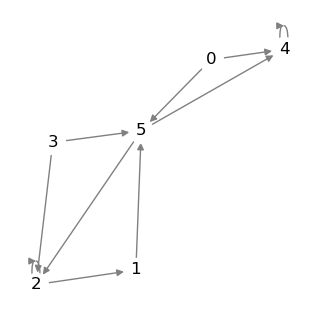

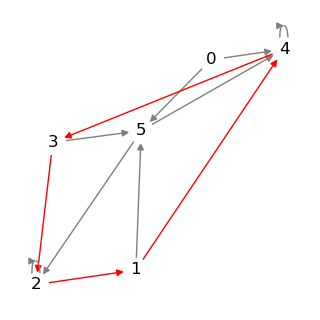

omitted edges (tensor([[0, 0],
        [5, 4]]), tensor([[4, 4],
        [1, 5]]))
omitted non edges tensor([[1, 3, 5, 5, 2, 4, 0, 0, 4, 4, 3, 2, 1, 4],
        [5, 5, 2, 4, 2, 4, 5, 4, 1, 5, 2, 1, 4, 3]])
new_edge_index tensor([[1, 3, 5, 5, 2, 4, 0, 0, 4, 4, 3, 2, 1, 4],
        [5, 5, 2, 4, 2, 4, 5, 4, 1, 5, 2, 1, 4, 3]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True, False, False, False, False,
        False, False, False, False])


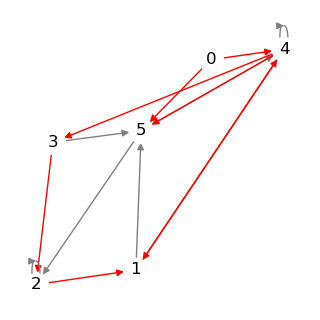

In [5]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5, 2, 2, 4],
                                     [5, 4, 5, 2, 5, 2, 4, 1, 2, 4]]))

# data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5, 2],
                                    #  [5, 4, 5, 2, 5, 2, 4, 1]]))
data.edge_attr = torch.ones(data.edge_index.shape[1]).bool()

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
test_p = 0.2
val_p = 0.2

#todo: test both get dyads to omit and omit dyads. 
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=test_p,
                                directed=True)
data_omitted1 = Data(edge_index=dyads_to_omit_test[1], edge_attr=dyads_to_omit_test[2])

# plot_directed_graph(data_omitted1)

print('omitted edges (B)', dyads_to_omit_test[0][0])
print('omitted non edges (C)', dyads_to_omit_test[0][1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)


#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=val_p/(1-test_p), directed=True)
data_omitted2 = Data(edge_index=dyads_to_omit_val[1], edge_attr=dyads_to_omit_val[2])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST what to look for: 1. that omitted non edges are 5 times that of omitted edges. 
#? TEST                   2. that the edges, omitted edges and omitted non edges are marked correctly in the
#? TEST                      edge_attr
#? TEST                   3. that the images have the correct omitted dyads


## DYAD OMITTION SANITY
Check that dyad omittion in the reparametrization is the same as the original 

In [7]:
# with clamiter

lorenz = False
ds = import_dataset('SmallDirected')
clamiter = ci.ClamIter(dim_feat=4,
                       lorenz=lorenz,
                       vanilla=True,
                       l1_reg=0,
                       directed=True)


ds.x = clamiter.init_node_feats(num_nodes=ds.num_nodes, init_type='small_gaus')
print(f'initial node features:\n {ds.x}')

edge_index_orig = ds.edge_index.clone()
edge_attr_orig = ds.edge_attr.clone()

dyads_to_omit = lp.omit_dyads_random(ds.edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(ds.num_edges).bool())


ds.edge_attr = dyads_to_omit[2]
ds.edge_index = dyads_to_omit[1]
#WHEN OMITTING IS THE PROBLEM!!!!
print(f'omitted edges containes_self_loops: {upyg.contains_self_loops(dyads_to_omit[0][0])}')
print(f'omitted non edges containes_self_loops: {upyg.contains_self_loops(dyads_to_omit[0][1])}')

grad_clamiter = clamiter(ds)
print(f'grad_clamiter: \n{grad_clamiter}')
# DEFINE THE EDGES AND NON EDGES TO OMIT

# plot_sparse_adj(ds.edge_index, (([dyads_to_omit[0][0], dyads_to_omit[0][1]], None)))





/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:315:::  
end of import_dataset
SmallDirected 
has 10 nodes 
and 22 edges. 
Graph is directed
Graph has self loops
initial node features:
 tensor([[0.9525, 0.8032, 0.8881, 0.8861],
        [0.9847, 1.0528, 0.8609, 0.8718],
        [0.8620, 0.8565, 0.9414, 0.8234],
        [1.0875, 0.8695, 0.9196, 0.8658],
        [0.8684, 0.9934, 0.9480, 0.7862],
        [0.8325, 0.9007, 0.9765, 1.0816],
        [0.7624, 0.9108, 1.0017, 0.9634],
        [0.8330, 0.9190, 0.9656, 0.9595],
        [0.6478, 0.7948, 0.8219, 0.9306],
        [0.9236, 1.0132, 0.8603, 0.9281]])
omitted edges containes_self_loops: False
omitted non edges containes_self_loops: False
grad_clamiter: 
tensor([[-3.9390, -3.6859, -7.8861, -8.1205],
        [-2.1364, -2.0764, -3.2748, -3.7362],
        [-9.1841, -9.0965, -6.7790, -6.8775],
        [-6.9733, -7.0697, -4.7396, -4.9900],
        [-7.1373, -7.0590, -6.2909, -6.8059],
  

grad_clamiter:
 tensor([[-3.9390, -3.6859, -7.8861, -8.1205],
        [-2.1364, -2.0764, -3.2748, -3.7362],
        [-9.1841, -9.0965, -6.7790, -6.8775],
        [-6.9733, -7.0697, -4.7396, -4.9900],
        [-7.1373, -7.0590, -6.2909, -6.8059],
        [-6.3121, -6.1815, -4.7780, -4.9783],
        [-6.7737, -6.7118, -7.1219, -7.2663],
        [-8.0203, -8.0009, -5.7751, -6.0658],
        [-6.1158, -5.9835, -8.7545, -9.1138],
        [-5.9957, -5.9200, -3.5505, -3.6752]])
grad_no_tricks:
 tensor([[-3.9390, -3.6859, -7.8861, -8.1205],
        [-2.1364, -2.0764, -3.2748, -3.7362],
        [-9.1841, -9.0965, -6.7790, -6.8775],
        [-6.9733, -7.0697, -4.7395, -4.9900],
        [-7.1373, -7.0590, -6.2909, -6.8059],
        [-6.3121, -6.1815, -4.7780, -4.9783],
        [-6.7737, -6.7118, -7.1219, -7.2663],
        [-8.0203, -8.0009, -5.7751, -6.0658],
        [-6.1158, -5.9835, -8.7545, -9.1138],
        [-5.9957, -5.9200, -3.5505, -3.6752]])
(grad_no_tricks- grad_clamiter)/grad_no_trick

/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../tests/tests.py:91: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /private/var/folders/nz/j6p8yfhx1mv_0grj5xl4650h0000gp/T/abs_83_m9l5ufr/croot/pytorch_1686041389610/work/aten/src/ATen/native/TensorShape.cpp:3281.)
  inner_prod = sender_i @ (B@receiver_other).T


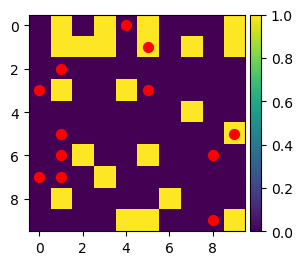

In [ ]:
# no tricks calc

edge_index = edge_index_orig
num_nodes = ds.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges

non_adj = 1 - upyg.to_dense_adj(edge_index)[0]
non_edge_index = torch.stack(torch.where(non_adj == 1))

edge_index_retained = dyads_to_omit[1][:, dyads_to_omit[2]]

#non_edge_index retained
omitted_non_edges_adj = torch.zeros((num_nodes, num_nodes)) if dyads_to_omit[0][1].numel() == 0 else upyg.to_dense_adj(dyads_to_omit[0][1], max_num_nodes=num_nodes)[0]
non_edge_index_retained_mat = non_adj - omitted_non_edges_adj
non_edge_index_retained = torch.stack(torch.where(non_edge_index_retained_mat == 1))



grad_no_tricks = calc_grad_no_tricks_directed(ds.x, edge_index_retained, non_edge_index_retained, lorenz=lorenz)
diff = grad_no_tricks - grad_clamiter
print('grad_clamiter:\n', grad_clamiter)
print('grad_no_tricks:\n' , grad_no_tricks)
print('(grad_no_tricks- grad_clamiter)/grad_no_tricks:\n', diff/grad_no_tricks)
print(f'max diff = {diff.abs().max()}')

# print('grad_no_tricks- grad_clamiter:\n', grad_no_tricks- grad_clamiter)
#todo: compare the grad no tricks to the clamiter forward function.
plot_sparse_adj(edge_index, (([dyads_to_omit[0][0], dyads_to_omit[0][1]], None)))
a=0
#but when omitting it's only the space component that is wrong...
# a problem that only happens when omitting and only to the space component...
#! i'm kind of thinking to reverse the probabilities... the disconnections might be too powerful



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 10 nodes 
and 17 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 


omitted edges containes_self_loops: True
omitted non edges containes_self_loops: True


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:336:::  

In function train. 
2025-09-28 20:32:46 starting optimization of ieclam on SmallDirected (DIRECTED) on device cpu

 configs_dict: 
{
    "clamiter_init": {
        "dim_feat": 4,
        "dim_attr": 64,
        "s_reg": 0.0,
        "l1_reg": 0.0,
        "T": 1,
        "hidden_dim": 64,
        "num_coupling_blocks": 32,
        "num_layers_mlp": 2
    },
    "feat_opt": {
        "lr": 1e-06,
        "n_iter": 1,
    

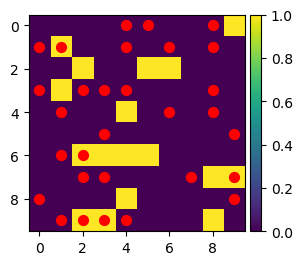

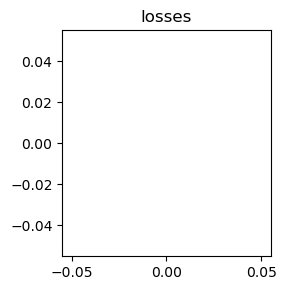

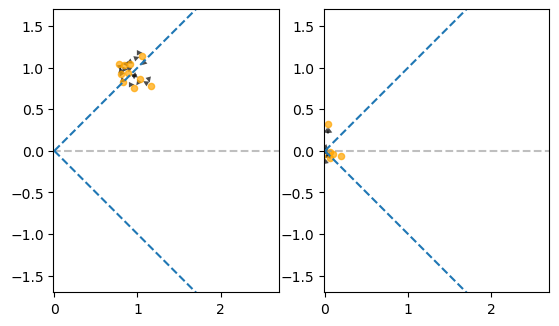

TEST accuracy.
Latest:
losses: None 
Best:
losses: None at iteration None


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:442:::  



FINISHED train 
 last accuracies:
test
key='losses': -39.84894561767578




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:458:::  

train_model_on_params on ieclam SmallDirected 
took 0.44281864166259766 seconds


TypeError: diag(): argument 'input' (position 1) must be Tensor, not list

In [ ]:
# DEFINE THE DATA AND NUMBER OF FEATURES
#todo: too much printing when doing this with trainer. use clamiter_directed instead

config_triplets = [['clamiter_init', 'dim_feat', 4],
                   ['clamiter_init', 'l1_reg', 0.0],
                   ['clamiter_init', 's_reg', 0.0],
                   ['feat_opt', 'n_iter', 1]]

trainer_clam = Trainer(
                    dataset_name='SmallDirected', 
                    model_name='ieclam', device='cpu',
                    config_triplets_to_change=config_triplets,
                    )
print(trainer_clam)

# DEFINE THE EDGES AND NON EDGES TO OMIT
edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges

dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())

print(f'omitted edges containes_self_loops: {upyg.contains_self_loops(dyads_to_omit[0][0])}')
print(f'omitted non edges containes_self_loops: {upyg.contains_self_loops(dyads_to_omit[0][1])}')
non_adj = 1 - upyg.to_dense_adj(edge_index)[0]
non_edge_index = torch.stack(torch.where(non_adj == 1))

edge_index_retained = dyads_to_omit[1][:, dyads_to_omit[2]]

#non_edge_index retained
omitted_non_edges_adj = upyg.to_dense_adj(dyads_to_omit[0][1], max_num_nodes=num_nodes)[0]
non_edge_index_retained_mat = non_adj - omitted_non_edges_adj
non_edge_index_retained = torch.stack(torch.where(non_edge_index_retained_mat == 1))


plot_sparse_adj(edge_index, (([dyads_to_omit[0][0], dyads_to_omit[0][1]], None)))

trainer_clam.train()
#! how to get the non_edge_index that was retained?
grad_no_tricks = calc_grad_no_tricks_directed(trainer_clam.data.x, edge_index_retained, non_edge_index_retained, lorenz=True)

#todo: compare the grad no tricks to the clamiter forward function.

In [ ]:
config_triplets = [['clamiter_init', 'dim_feat', 4]]
trainer_clam = Trainer(
                    dataset_name='SmallDirected', 
                    model_name='ieclam', device='cpu',
                    config_triplets_to_change=config_triplets)

edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges

dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())

non_adj = 1 - upyg.to_dense_adj(edge_index)[0]
non_edge_index = torch.stack(torch.where(non_adj == 1))



# trainer_clam.create_clamiter(param_dictconfig_triplets = [['clamiter_init', 'dim_feat', 4]])
# trainer_clam.data.x = trainer_clam.clamiter.init_node_feats(num_nodes=trainer_clam.data.num_nodes, init_type='small_gaus')


# DEFINE THE EDGES TO OMIT
edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges
dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())
# ==================================
#todo: make the calculation and anomaly detection experiments
#calculate with DIRECT SUMMATION and no trick
# these are the non edges, but there is probably a better way to get them


mask_edges_omitted = edge_mask_of_selected_edges(edge_index, dyads_to_omit[0])
mask_non_edges_omitted = edge_mask_of_selected_edges(non_edge_index, dyads_to_omit[1])

edge_index_filtered = edge_index[:, ~mask_edges_omitted]
non_edge_index_filtered = non_edge_index[:, ~mask_non_edges_omitted]
grad_no_tricks = calc_grad_no_tricks(trainer_clam.data.x, edge_index_filtered, non_edge_index_filtered, lorenz=True)
#======================================================

# SUMMATION TRICK in clamiter forward function
trainer_clam.data.edge_index, trainer_clam.data.edge_attr = trainer_clam.omit_dyads(dyads_to_omit)
node_mask = torch.ones(trainer_clam.data.x.shape[0], dtype=torch.bool)

grad_trainer = trainer_clam.clamiter.forward(trainer_clam.data, node_mask=node_mask)
# ======================================================

#? TEST direct summation == summation trick
assert torch.allclose(grad_no_tricks, 2*grad_trainer, atol=1e-4), f'''
the no tricks gradient is not the same as the gradient in trainer->clamiter->forward
grad_no_tricks: {grad_no_tricks}
2*grad_trainer: {2*grad_trainer}
grad_trainer: {grad_trainer}
'''
#? ==================================================
if verbose:
    printd('omitted the dyads and compared the gradient calculation with direct sum and the summation trick')
    #! notice that the edge_index is changed by the omit edges function!
    plot_adj(to_dense_adj(trainer_clam.data.edge_index_original)[0],dyads_to_omit)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 14 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 11 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 




AttributeError: 'tuple' object has no attribute 'unsqueeze'

# Undirected

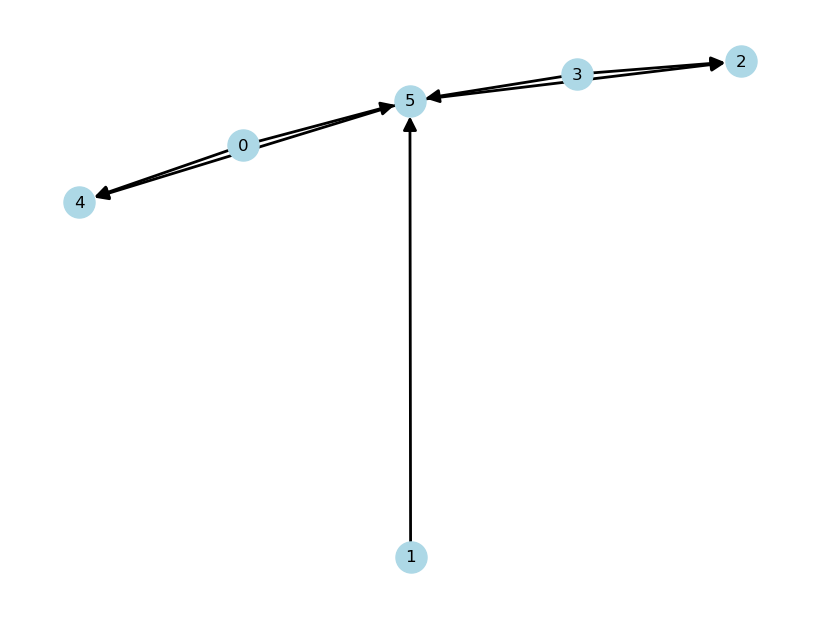

IndexError: tuple index out of range

In [ ]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()
plot_directed_graph(data)
data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)


#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

# plot_directed_graph(data_omitted1)

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST
